<a href="https://colab.research.google.com/github/geoalm-hub/TechChallenge---Fase-2/blob/main/TechChallenge_Fase_2_Case_Wine_Quality_An%C3%A1lise_e_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Case Wine Quality

## Fase 1: Compreensão do Problema
Este desafio propõe desenvolver um modelo de classificação capaz de prever a qualidade de um vinho com base em suas características físico-químicas com base no dataset  Wine Quality Dataset, transformando dados em insights + transformação da variável de qualidade em classificação
binária. Onde:

> Vinho de Alta Qualidade: nota ≥ 7

> Vinho de Baixa/Média Qualidade: nota < 7

O conjunto de dados (WineQT.csv) contém variáveis como:

* Acidez fixa (fixed acidity);

* Acidez volátil (volatile acidity);

* Ácido cítrico (citric acid);

* Açúcar residual (residual sugar);

* Cloretos (chlorides);

* Dióxido de enxofre livre (free sulfur dioxide);

* Dióxido de enxofre total (total sulfur dioxide);

* Densidade (density);

* pH;

* Sulfatos (sulphates);

* Teor alcoólico (alcohol);

* Qualidade do vinho (quality).

##Fase 2: EDA

###Conhecendo a Base

In [76]:
#Libs = bibliotecas importantes foram importadas durante a exceução do EDA

import pandas as pd

In [77]:
#Importação da base de dados.
df = pd.read_csv ("WineQT.csv")

In [78]:
#Análise das linhas e colunas
df.shape

(1143, 13)

In [79]:
#Análise das 5 primeiras linhas
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [80]:
#Informações da nossa base de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [81]:
#Análise de qualidade: nota máxima e mínima
print ('Nota máxima:', df ['quality'].max())
print ('Nota mínima:', df ['quality'].min())

Nota máxima: 8
Nota mínima: 3


### Análise da Consistência dos Dados

In [82]:
#Análise de valores nulos
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [83]:
#Análise de valores duplicados
df.duplicated().sum()

np.int64(0)

Conforme analisado, não há valores nulos ou duplicados na base.

###Análise Exploratória dos Dados

Agora, vou construir uma análise inicial para conhecer os dados. Primeiro, irei aplicar a análise estatística descritiva dos dados e fazer algumas inferências:

In [84]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


> Média de qualidade dos vinhos é de 5.65
> Desvio padrão é de 0.80

Se o desvio padrão é baixo em relação à média, isso significa que a maioria dos valores estão próximos da média e que os dados estão mais concentrados em torno da média.

In [85]:
#Buscando possíveis correlações
df.groupby ('quality')["density"].mean()

,density
quality,
3,0.997682
4,0.996669
5,0.997073
6,0.996610
7,0.996071
8,0.995553


In [86]:
df.groupby ('quality')["citric acid"].mean()

,citric acid
quality,
3,0.211667
4,0.165758
5,0.240124
6,0.263680
7,0.386573
8,0.432500


In [87]:
df.groupby ('quality')["alcohol"].mean()

,alcohol
quality,
3,9.691667
4,10.260606
5,9.902277
6,10.655339
7,11.482634
8,11.937500


In [88]:
df.groupby ('quality')["pH"].mean()

,pH
quality,
3,3.361667
4,3.391212
5,3.302091
6,3.323788
7,3.287133
8,3.240625


In [89]:
df.groupby ('quality')["residual sugar"].mean()

,residual sugar
quality,
3,2.666667
4,2.566667
5,2.540476
6,2.444805
7,2.760140
8,2.643750


Vamos aos gráficos:

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
df_maior_classificacao_qualidade = df.groupby ('quality')[['alcohol','pH','citric acid']].mean().sort_index(ascending = False)

In [92]:
df_maior_classificacao_qualidade

,alcohol,pH,citric acid
quality,,,
8,11.937500,3.240625,0.432500
7,11.482634,3.287133,0.386573
6,10.655339,3.323788,0.263680
5,9.902277,3.302091,0.240124
4,10.260606,3.391212,0.165758
3,9.691667,3.361667,0.211667


In [93]:
df['classificacao_qualidade'] = ['Vinho de alta qualidade' if v >= 7 else 'Vinho de baixa/média qualidade' for v in df['quality']]

In [94]:
df['classificacao_qualidade'].value_counts(normalize=True) * 100

,proportion
classificacao_qualidade,
Vinho de baixa/média qualidade,86.089239
Vinho de alta qualidade,13.910761


Fica evidente que a nossa base tem maior quantidade de vinhos classficados como "baixa/média qualidade", ou seja, possuem nota < 7.

> Vinhos de baixa/média qualidade representam 86% da base, já vinhos de alta qualidade representam 14% da base, um desbalanceamento significativo.

Esse ponto é crucial!

Imagina um modelo "preguiçoso" que simplesmente prevê "baixa/média qualidade" pra tudo, sem aprender nada de verdade. Qual seria a acurácia dele?

"86%"... exato! Um modelo que não aprendeu absolutamente nada de útil ainda assim pareceria "86% correto". A famosa armadilha da acurácia em datasets desbalanceados. Quando uma classe é muito mais frequente que a outra no conjunto de dados, o modelo que irei contruir irá dar mais importância a essa classe, o que poderá levar a uma classificação incorreta das classes minoritarárias.

Voltarei nisso mais tarde.

In [95]:
matriz_correlacao = df.corr(numeric_only=True)

correlacao_qualidade = matriz_correlacao ['quality']

display (correlacao_qualidade)

,quality
fixed acidity,0.121970
volatile acidity,-0.407394
citric acid,0.240821
residual sugar,0.022002
chlorides,-0.124085
free sulfur dioxide,-0.063260
total sulfur dioxide,-0.183339
density,-0.175208
pH,-0.052453
sulphates,0.257710


A tabela indiaca algumas correlações, mas a visualização não é clara. Vou resolver isso com um mapa de calor.

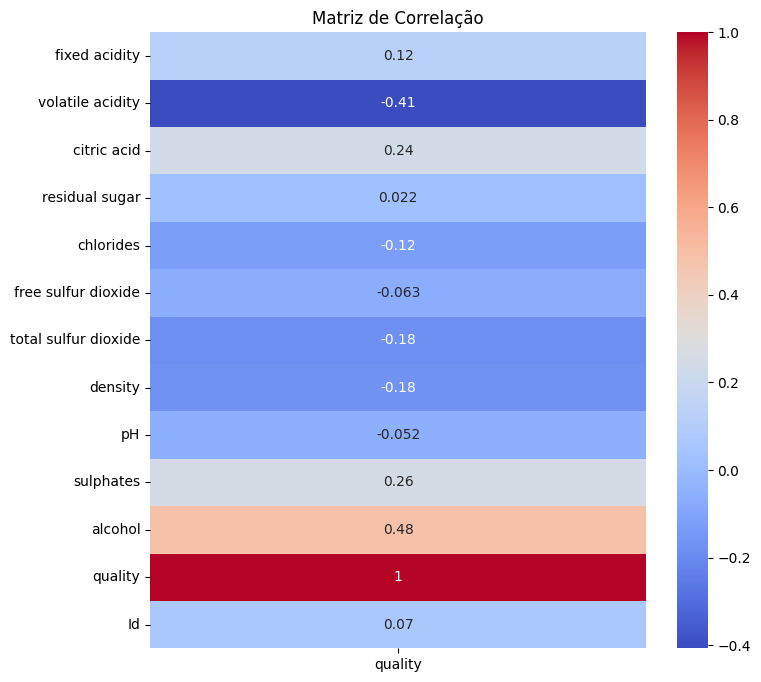

In [96]:
fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap (correlacao_qualidade.to_frame(), annot = True, cmap = 'coolwarm')
plt.title('Matriz de Correlação')
plt.show()


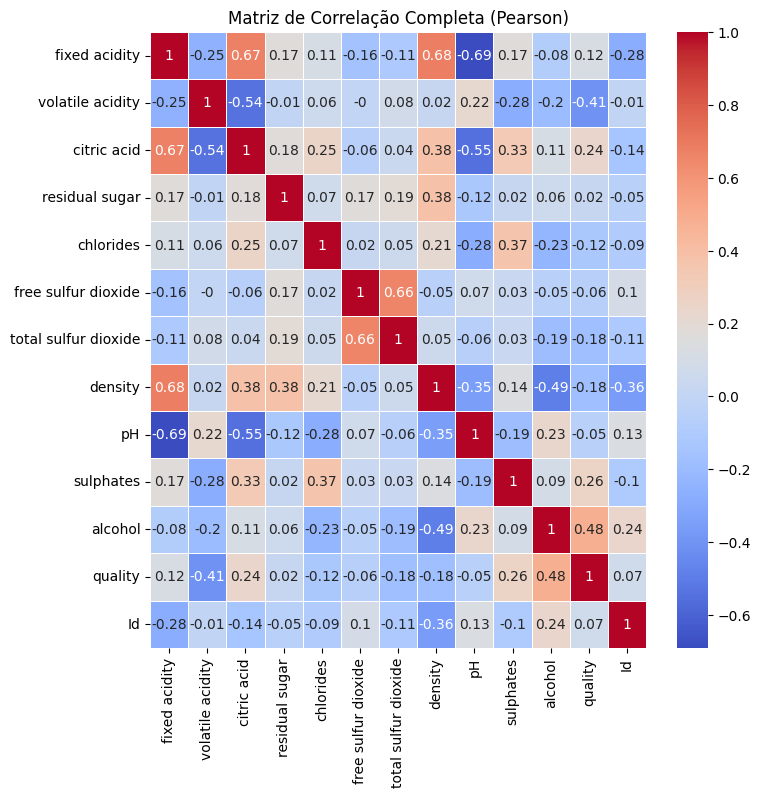

In [97]:
fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(data=matriz_correlacao.round(2), annot=True, linewidths= 0.6, cmap='coolwarm')
plt.title('Matriz de Correlação Completa (Pearson)')
plt.show()

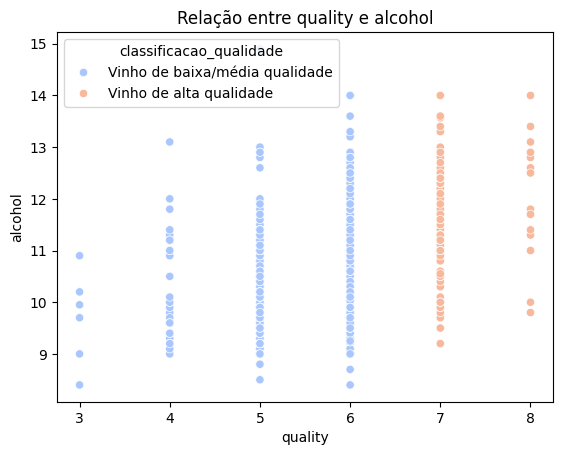

In [98]:
sns.scatterplot (x= "quality", y= 'alcohol', hue = 'classificacao_qualidade', data = df, palette = 'coolwarm')
plt.xlabel ('quality')
plt.ylabel ('alcohol')
plt.title ('Relação entre quality e alcohol')
plt.show()

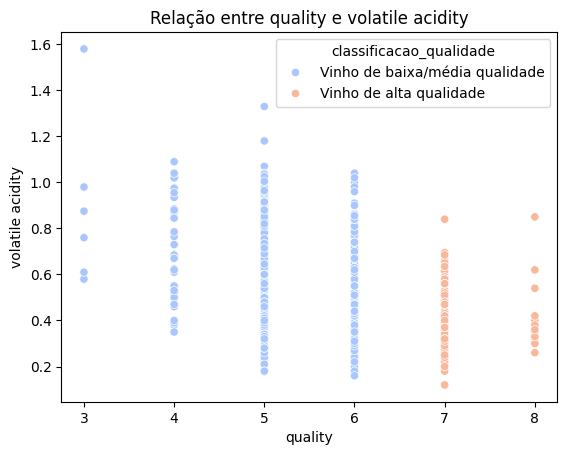

In [99]:
sns.scatterplot (x= "quality", y= 'volatile acidity', hue = 'classificacao_qualidade', data = df, palette = 'coolwarm')
plt.xlabel ('quality')
plt.ylabel ('volatile acidity')
plt.title ('Relação entre quality e volatile acidity')
plt.show()

Os dados indicam que teor alcoólico e acidez volátil têm influência na classificação de um vinho. Nos aprofundaremos nisso em breve.

Apenas a título de curiosidade, identifiquei, abaixo, a multicolinearidade entre fixed acidity, pH e density, o que é esperado quimicamente, já que pH é uma medida direta de acidez. Isso não invalida os modelos que usarei mais pra frente (árvore de decisão e KNN são relativamente robustos a essa questão), mas seria um ponto de atenção caso um modelo linear como regressão logística fosse aplicado.

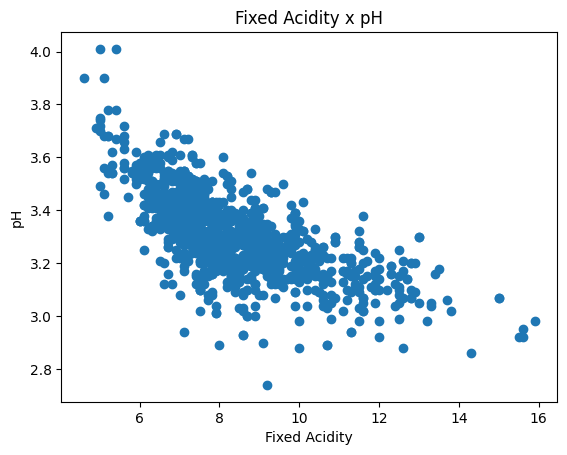

In [100]:
plt.scatter("fixed acidity", "pH", data=df)
plt.xlabel("Fixed Acidity")
plt.ylabel("pH")
plt.title("Fixed Acidity x pH")
plt.show()

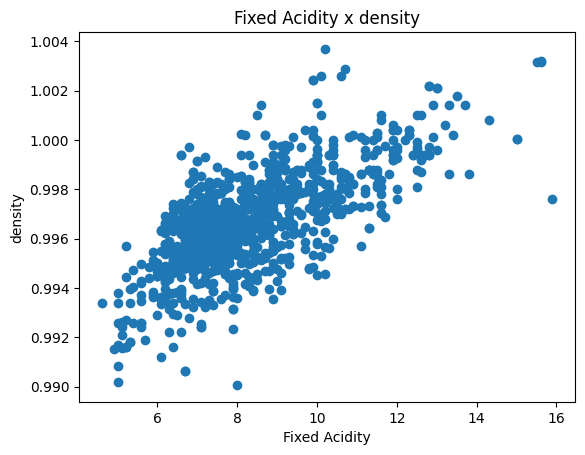

In [101]:
plt.scatter("fixed acidity", "density", data=df)
plt.xlabel("Fixed Acidity")
plt.ylabel("density")
plt.title("Fixed Acidity x density")
plt.show()

###Análise de Outliers

In [102]:
colunas_numericas = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                      'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                      'density', 'pH', 'sulphates', 'alcohol']

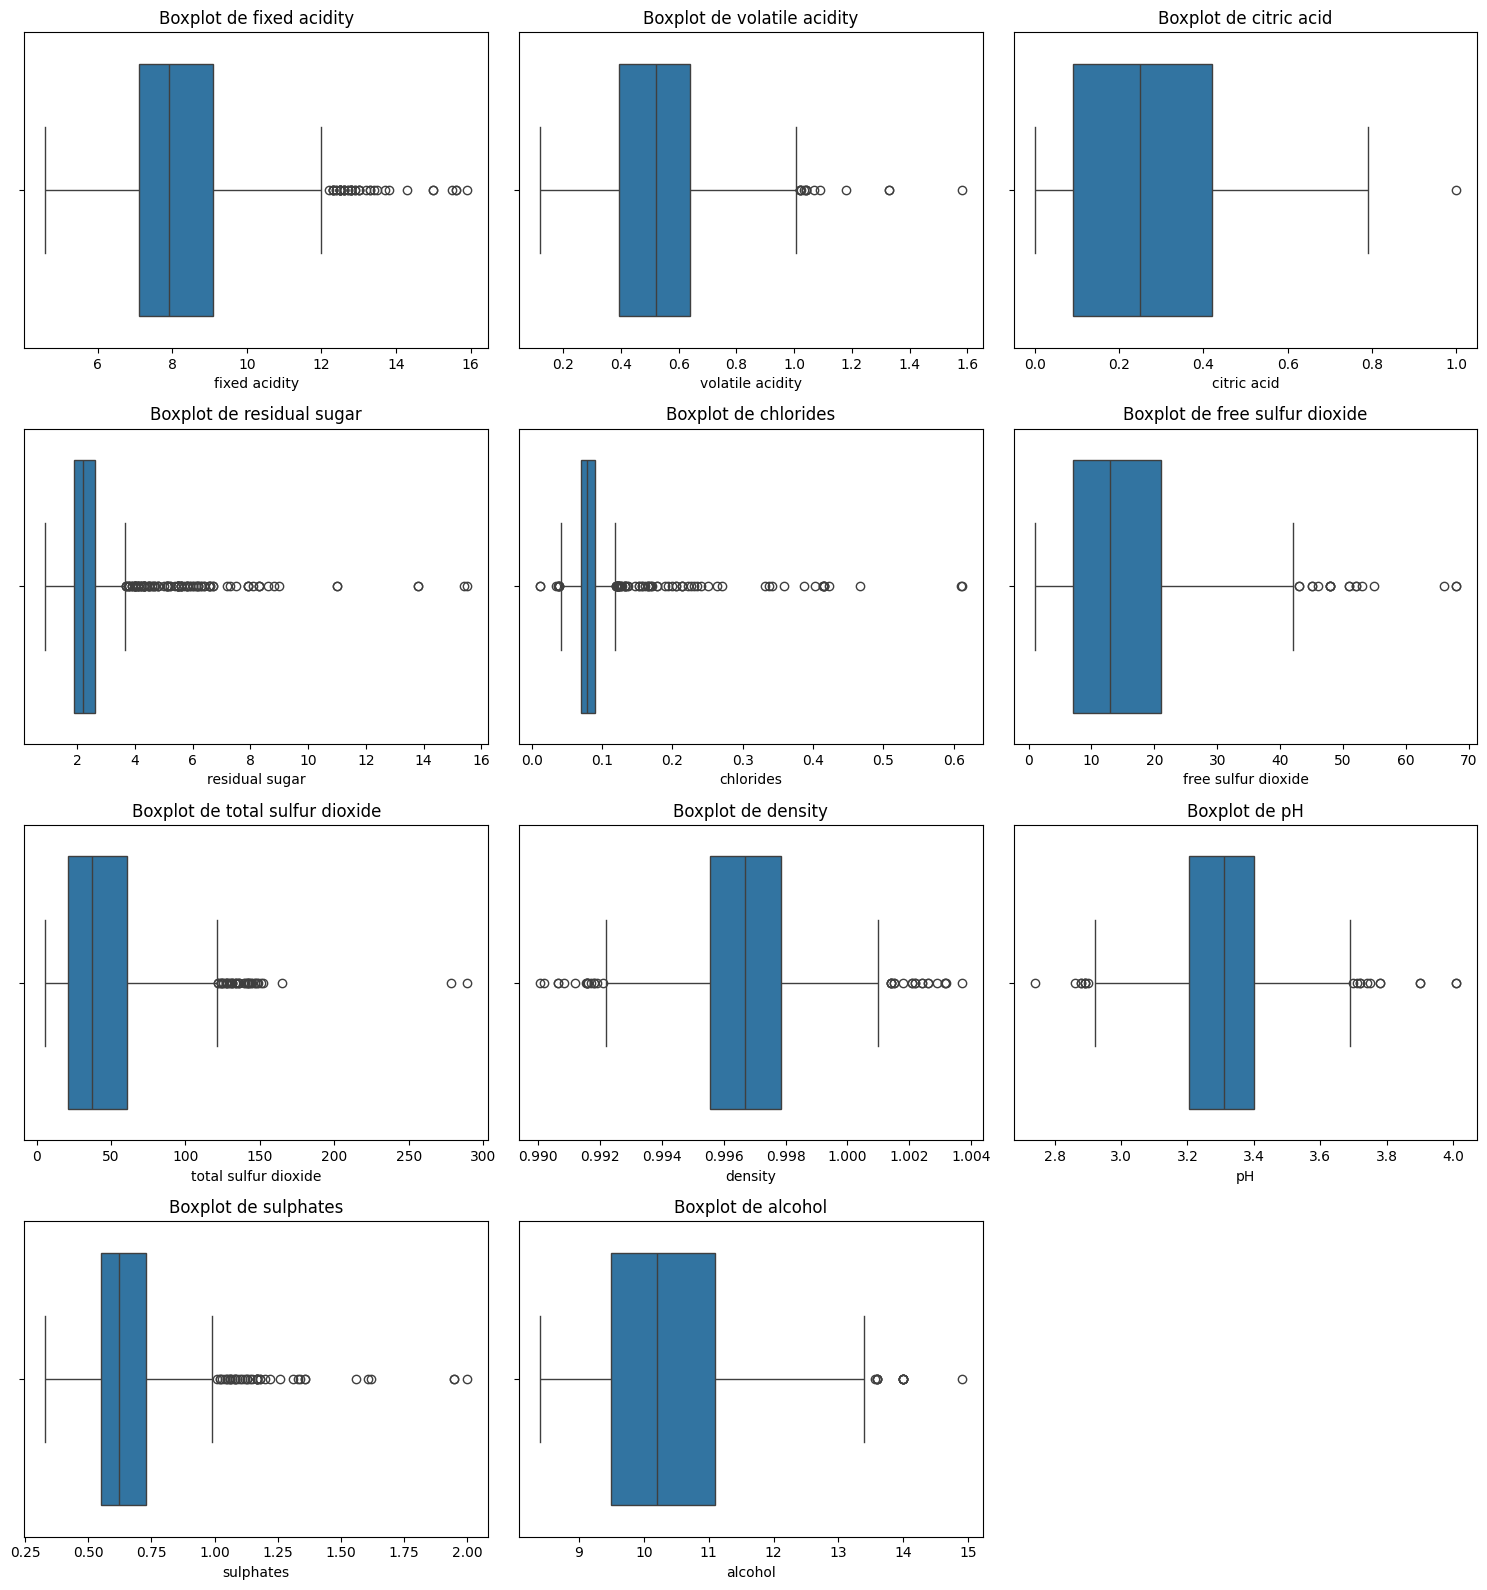

In [103]:
plt.figure(figsize=(15, 16))

for i, col in enumerate(colunas_numericas):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

Leitura de outliers:

* residual sugar: caixa bem estreita (a maioria dos vinhos entre ~2 e 4), mas uma cauda longa de pontos até 16 — bastante outliers à direita.

* fixed acidity: alguns pontos isolados acima de ~14, mas a caixa em si é mais "larga" (maior variabilidade natural).

* volatile acidity: outliers acima de 1.0, com um ponto isolado perto de 1.6.
citric acid: só 1 outlier isolado, bem mais "limpo" que as outras.

Os pontos fora da caixa não parecem erro de medição, mas sim, variação natural do processo de vinificação. Entender isso importa porque, se fosse erro, eu removeria eles da base. Por serem variação real da produção (ex: um vinho naturalmente mais doce), irei mante-los, mas irei explorá-los um pouco mais:

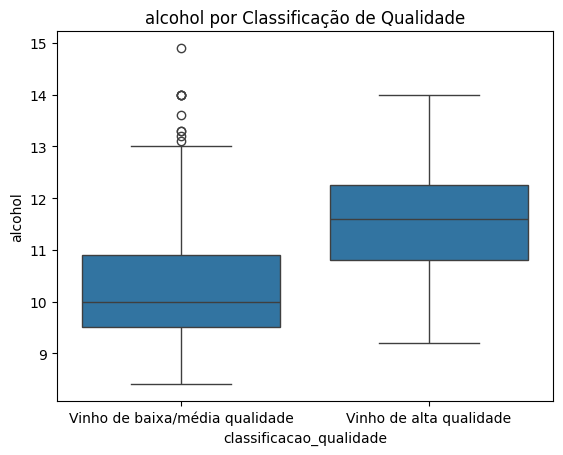

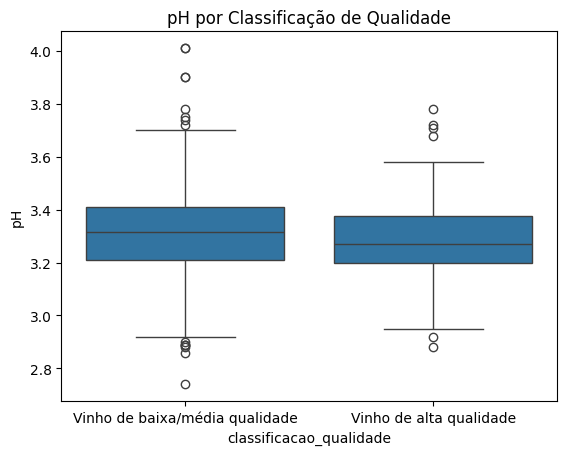

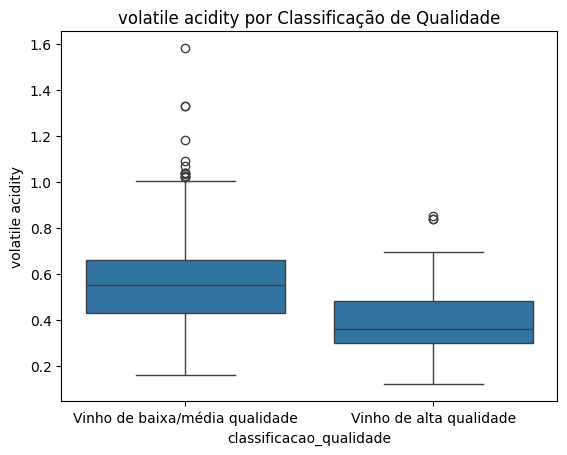

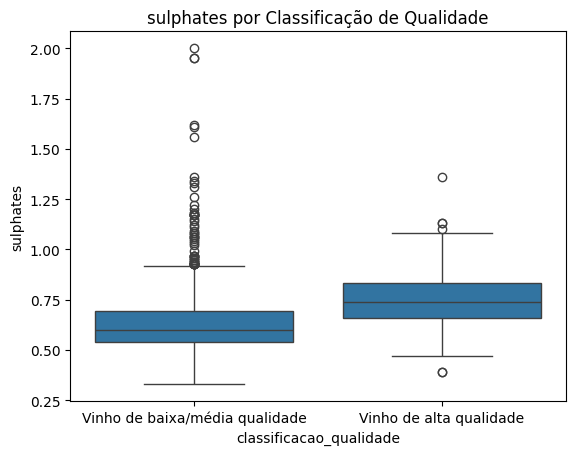

In [104]:
colunas_investigar = ['alcohol', 'pH', 'volatile acidity', 'sulphates']

for col in colunas_investigar:
    sns.boxplot(x='classificacao_qualidade', y=col, data=df)
    plt.title(f'{col} por Classificação de Qualidade')
    plt.show()

Meu objetivo era analisar se os outliers variam por conta do processo de produção.

No entanto, na base de dados analisada, não há nenhuma coluna que identifique o método de produção, tipo de vinho, região ou vinícola... só características físico-químicas e a nota de qualidade. Ou seja, não tem como isolar diretamente "esses outliers vieram do método X" porque essa informação não existe nos dados.

O que fpo possível fazer, e que ainda dá uma pista relevante: verificar se os outliers têm alguma relação com a classificação de qualidade. Será que os vinhos "outliers" em residual sugar ou volatile acidity, por exemplo, tendem a ser mais vinhos de alta ou de baixa/média qualidade? Isso não prova "método de produção", mas dá indício se aquele valor extremo é uma característica que "ajuda" ou "atrapalha" a nota final.

Observando os boxplots:

Alcohol: as caixas praticamente não se sobrepõem, "alta qualidade" tem uma caixa inteira acima da mediana de "baixa/média". Além disso, os outliers aqui estão concentrados no grupo de baixa/média qualidade (pontos entre 13-15% de álcool, sendo classificados como baixa qualidade mesmo assim). Isso é um indício de que teor alcoólico alto ajuda, mas sozinho não garante nota alta, outros fatores também entram na jogada.

pH: as duas caixas ficam quase idênticas, com outliers nos dois grupos. Isso bate com o que a árvore já tinha te mostrado, pH foi a variável com menor importância (1.4%). Visualmente, você está confirmando com os próprios olhos o que o modelo calculou matematicamente.

Volatile acidity: aqui o padrão é bem nítido, "baixa/média qualidade" tem uma caixa mais alta e outliers extremos (até 1.6), enquanto "alta qualidade" tem caixa mais baixa e outliers bem mais discretos (só ~0.85). Isso reforça a relação negativa.

Sulphates: também bem distinto, "alta qualidade" tem uma caixa inteira deslocada pra cima, com outliers bem menos extremos. "Baixa/média" tem uma quantidade grande de outliers (muitos pontos acima de 1.0). Isso valida por que a árvore deu tanto peso a essa variável (11%), mesmo a correlação linear sendo mais modesta (0.26), a relação parece mais robusta quando olho a distribuição toda, não só a correlação.

Novamente, os outliers se distribuem de forma coerente com o padrão de qualidade (ex: outliers de alta acidez volátil aparecem majoritariamente em vinhos ruins).

## Fase 3: Pré-processamento de Dados

In [105]:
from sklearn.model_selection import train_test_split

X = df[colunas_numericas]
y = df['classificacao_qualidade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [106]:
print(X_train.shape)
print(X_test.shape)

(857, 11)
(286, 11)


>X_train: 857 linhas (75%)

>X_test: 286 linhas (25%)

In [107]:
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

classificacao_qualidade
Vinho de baixa/média qualidade    86.114352
Vinho de alta qualidade           13.885648
Name: proportion, dtype: float64
classificacao_qualidade
Vinho de baixa/média qualidade    86.013986
Vinho de alta qualidade           13.986014
Name: proportion, dtype: float64


X_train: 857 linhas * 11 colunas

X_test: 286 linhas * 11 colunas

857 + 286 = 1143 → bate certinho com o total do dataset.

Proporção mantida quase idêntica nos dois: 86.1% / 13.9% no treino, 86.0% / 14.0% no teste. A estratificação funcionou exatamente como esperado.

Agora sim posso voltar pra normalização/padronização, já com a ordem certa (treino separado do teste, sem vazamento de dados).

In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [109]:
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

Conceito do StandardScaler (padronização/Z-score): cada coluna passa a ter média 0 e desvio padrão 1 — todas na "mesma régua".

In [110]:
X_train_scaled.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,8.570000e+02,8.570000e+02,8.570000e+02,8.570000e+02,8.570000e+02,8.570000e+02,8.570000e+02,8.570000e+02,8.570000e+02,8.570000e+02,8.570000e+02
mean,-1.761848e-16,-7.461942e-17,-8.031952e-17,-8.705599e-17,1.803303e-16,6.425561e-17,6.218285e-18,-1.882068e-15,-1.898650e-15,7.337577e-16,-2.217855e-16
std,1.000584e+00,1.000584e+00,1.000584e+00,1.000584e+00,1.000584e+00,1.000584e+00,1.000584e+00,1.000584e+00,1.000584e+00,1.000584e+00,1.000584e+00
min,-2.110202e+00,-2.254636e+00,-1.369228e+00,-1.199846e+00,-1.774107e+00,-1.436447e+00,-1.187331e+00,-3.446798e+00,-2.874986e+00,-1.561207e+00,-1.891518e+00
25%,-6.933710e-01,-7.208430e-01,-9.600830e-01,-4.657359e-01,-3.690567e-01,-8.525105e-01,-7.410470e-01,-5.961967e-01,-6.556894e-01,-6.300917e-01,-8.730790e-01
50%,-2.399851e-01,-6.350321e-02,-3.950615e-02,-2.455029e-01,-1.510317e-01,-2.685743e-01,-2.650105e-01,-1.676409e-02,-2.160475e-02,-2.227288e-01,-2.249814e-01
75%,4.967671e-01,5.938365e-01,8.299276e-01,4.814117e-02,9.121828e-02,5.100073e-01,4.787964e-01,5.833626e-01,6.124799e-01,4.174129e-01,6.082870e-01
max,4.123855e+00,5.742998e+00,2.517652e+00,9.518161e+00,9.248267e+00,5.084174e+00,7.202811e+00,3.599516e+00,4.416988e+00,7.517166e+00,3.293263e+00


Desvio padrão: ~1.0006 em todas as colunas, todas na mesma escala agora.

Isso confirma que a padronização funcionou e que fixed acidity e chlorides agora "pesam" igual numa eventual conta de distância.

## Fase 4: Desenvolvimento de Modelos

In [111]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

KNN (K-Nearest Neighbors):

Pra classificar um vinho novo, ele olha pros K vizinhos mais próximos com base na distância entre as features (por isso a padronização essencial) e "vota": se a maioria dos vizinhos é "alta qualidade", ele classifica como alta qualidade.

Árvore de Decisão:

Já essa funciona com uma sequência de perguntas tipo "sim/não" sobre as features (ex: "álcool > 11%? Se sim, vá por aqui; se não, vá por ali"), até chegar numa folha final que dá o veredito. Ela não precisa de padronização pra funcionar bem (só o KNN é sensível a escala), mas como já está padronizado, não tem problema nenhum em usar os mesmos dados escalados nos dois.

In [112]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [113]:
# KNN (k=6, sem SMOTE)
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# Árvore (sem SMOTE)
arvore = DecisionTreeClassifier(random_state=42)
arvore.fit(X_train_scaled, y_train)
y_pred_arvore = arvore.predict(X_test_scaled)

# KNN (k=3, com SMOTE)
knn_smote = KNeighborsClassifier(n_neighbors=3)
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_knn_smote = knn_smote.predict(X_test_scaled)

# Árvore (com SMOTE)
arvore_smote = DecisionTreeClassifier(random_state=42)
arvore_smote.fit(X_train_smote, y_train_smote)
y_pred_arvore_smote = arvore_smote.predict(X_test_scaled)

##Fase 5: Avaliação de Modelos

Inicialmente eu havia testado o modelo KNN = 6, porém, em uma das aulas a prof usou KNN = 3. Por isso, decidi testar ambos os modelos.

O KNN com k=3 + SMOTE teve o melhor f1-score entre todas as versões do KNN (0.52), melhorou tanto a precision (0.35→0.41) quanto manteve um recall alto (0.72), comparado à versão com k=6+SMOTE.

Agora, por que diminuir K (de 6 pra 3) melhorou a precision?

Pensando na lógica do "voto", com k=6, cada previsão é decidida pela maioria entre 6 vizinhos, isso "suaviza" a decisão, fazendo uma média mais ampla da vizinhança, o que tende a favorecer a classe majoritária (mais fácil ter 4+ vizinhos "baixa/média" por perto, mesmo perto da fronteira). Com k=3, a decisão fica mais "sensível" aos vizinhos mais imediatos, o modelo confia mais no padrão local exato, o que pode ajudar a capturar melhor os poucos vizinhos genuinamente parecidos com um vinho de alta qualidade.

Isso tem uma contrapartida, porém: k muito baixo (tipo k=1) deixa o modelo mais sensível a ruído, um único vizinho "estranho" pode virar o voto inteiro. Geralmente existe um "ponto ideal" de k, nem muito baixo nem muito alto, e ele é encontrado testando vários valores.

Ainda assim, a Árvore + SMOTE é a que melhor equilibra os dois lados, mantém a mesma precision da árvore original (0.50, então não piora a confiabilidade quando aponta "alta qualidade"), mas melhora bastante o recall (0.50 → 0.65) e tem o melhor f1-score de todos os 4 (0.565). Ela também bate o KNN k=6 em recall sem sacrificar tanto a precision quanto o KNN k=3+SMOTE sacrificou.



In [114]:
y_train_smote.value_counts()

,count
classificacao_qualidade,
Vinho de baixa/média qualidade,738
Vinho de alta qualidade,738


As duas classes agora têm exatamente 738 exemplos cada no conjunto de treino balanceado (o SMOTE trouxe a minoritária pro mesmo patamar).

In [115]:
from sklearn.metrics import classification_report

resultados = {
    'KNN (k=6)': classification_report(y_test, y_pred_knn, output_dict=True),
    'KNN (k=3) + SMOTE': classification_report(y_test, y_pred_knn_smote, output_dict=True),
    'Árvore': classification_report(y_test, y_pred_arvore, output_dict=True),
    'Árvore + SMOTE': classification_report(y_test, y_pred_arvore_smote, output_dict=True),
}

comparacao = pd.DataFrame({
    modelo: {
        'precision': r['Vinho de alta qualidade']['precision'],
        'recall': r['Vinho de alta qualidade']['recall'],
        'f1-score': r['Vinho de alta qualidade']['f1-score'],
        'accuracy': r['accuracy']
    }
    for modelo, r in resultados.items()
}).T.round(3)

comparacao

,precision,recall,f1-score,accuracy
KNN (k=6),0.528,0.475,0.500,0.867
KNN (k=3) + SMOTE,0.408,0.725,0.523,0.815
Árvore,0.500,0.500,0.500,0.860
Árvore + SMOTE,0.500,0.650,0.565,0.860


##Fase 6: Interpretação dos Resultados

Precision responde: "das vezes que o modelo disse 'alta qualidade', quantas realmente eram?"

Recall responde: "de todos os vinhos que realmente eram 'alta qualidade', quantos o modelo conseguiu identificar?"


Pensando no contexto do negócio (uma vinícola querendo identificar vinhos de alta qualidade pra, digamos, precificar melhor ou destacar em um lançamento)é pior o modelo errar dizendo que um vinho bom é ruim (baixo recall) do que dizer que um vinho ruim é bom (baixa precision).

Se a precision é baixa, significa que o modelo está "enganando" o fornecedor/vinícola, dizendo que um vinho é bom quando não é.

O outro lado (recall baixo) seria o modelo deixar passar vinhos bons classificando-os como ruins, um "desperdício" de oportunidade, mas menos arriscado que vender/promover algo ruim como premium.

Olhando a tabela acima:

KNN: o recall disparou (0.47 → 0.78), ele passou a "pegar" muito mais vinhos de alta qualidade de fato. Mas a precision caiu bastante (0.53 → 0.35), ou seja, ele agora "chuta" alta qualidade com mais frequência, e erra mais nesse chute. Mas, baseado no que defini como prioridade (não confundir vinho ruim com bom), isso é uma piora pro critério de negócio, mesmo o modelo "parecendo" melhor em outras métricas.

Já a Árvore com SMOTE: manteve a mesma precision (0.50) e melhorou o recall (0.50 → 0.65) e o f1-score (0.50 → 0.57), ou seja, ela conseguiu identificar mais vinhos bons sem piorar a taxa de acerto quando aponta "alta qualidade". Isso é uma melhora mais "limpa" em relação ao critério de negócio.

O resultado é bem frustrante, justamente pelo fato dos valores paracerem "baixos". Mas aqui vale a reflexão de que não existe modelo perfeito.

Além disso, a limitação de desempenho pode refletir também a natureza da avaliação sensorial de qualidade, que nem sempre é totalmente explicada pelas variáveis físico-químicas disponíveis. Pelo contrário, a "qualidade" é uma nota humana e subjetiva, dada por degustadores, baseada em aroma, sabor, equilíbrio.

As 11 variáveis físico-químicas não capturam tudo isso. É esperado que o modelo tenha um teto de desempenho, porque parte da variável que ele está tentando prever nem está totalmente representada nos dados de entrada (a pequena quantidade de exemplos de "alta qualidade", só 159).

###Variáveis que Influenciam a Previsão

In [116]:
importancias = pd.Series(arvore_smote.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importancias)

alcohol                 0.412863
sulphates               0.113267
volatile acidity        0.112614
fixed acidity           0.066139
citric acid             0.063890
total sulfur dioxide    0.057370
chlorides               0.050484
free sulfur dioxide     0.043219
residual sugar          0.036257
density                 0.029740
pH                      0.014157
dtype: float64


O resultado bate bastante com a intuição que a correlação já tinha sugerido lá no começo!

Top 3 variáveis, segundo a árvore:

alcohol (41%): de longe a mais importante, consistente com aquela correlação de 0.48 que calculei lá na EDA.

sulphates (11%): não estava tão em destaque nas correlações simples (era 0.26), mas ganhou bastante peso aqui. Isso acontece porque feature_importances_ captura relações que podem não ser lineares — a correlação de Pearson só enxerga relações "em linha reta", enquanto a árvore consegue capturar padrões mais complexos (ex: "sulphates só importa quando combinado com outro fator").

volatile acidity (11%): também bateu com a correlação negativa forte (-0.41) que você já tinha identificado.

pH (1.4%) ficou como a menos relevante: também bate com a correlação praticamente nula (-0.05).

Importante: alcohol é o fator mais determinante para que o vinho seja classificado como "alta qualidade" (0.412863), e álcool vem da fermentação (leveduras convertendo açúcar em álcool).

Na prática, isso sugere que o enólogo deve monitorar/controlar de perto durante a produção.

Quando cruzamos com o volatile acidity (que geralmente está associada a contaminação bacteriana ou oxidação durante o processo), o contrate distoa, conforme alcool aumenta e acidez volatil dominue, maiores as chances de um vinho ser classificado como "alta qualidade".

Ou seja, seguir um padrão de produção com alto rigor nos processo de higiene, para que não haja contaminações externas, pode impactar signitivamente no produto final. Por exemplo: não permitir que o produto seja exposto ao ar durante a fabricação para não acelerar a oxidação.

Por fim, o sulfato, que apresentava correlação linear discreta no heatmap (0.26), ganhou mais destaque na árvore (11% de importância), isso sugere uma relação não-linear com a qualidade, que a árvore conseguiu capturar melhor do que a correlação simples. Do ponto de vista produtivo, isso reforça a importância de monitorar o nível de sulfatos, geralmente ligado à conservação e controle microbiológico do vinho, mesmo que seu efeito isolado pareça pequeno à primeira vista.